# NLP Assignment 04-06
**Muhamad Fadhli Akbar(Cortana)**

---

## 1. Analisis Sentimen

* Buatlah `sentiment analysis` menggunakan dataset `IMDB_Dataset` (IMDB_Dataset.csv) berdasarkan nilai polaritas.
    * load dataset menggunakan read_cs, kemudian bentuk menjadi dataframe.
    * Buat sentiment analysis berdasarkan kolom review.
    * Perhatikan notebook pada resources modul 4 untuk cara mengerjakan.
    * Dari nilai polaritas tentukan apakah suatu review positive atau negative.
    *
* Boleh menggunakan textblob maupun vader (salah satu saja).
* Bandingkanlah hasil `sentiment analysis` dengan `ground truth` (kolom
  sentiment). Cukup lakukan secara manual seperti tulis kesimpulan dalam markdown/comment, atau dapat tambahkan kolom dalam dataframe yang berisi true/false.


In [1]:
import numpy as np
import pandas as pd

In [3]:
imdb = pd.read_csv('IMDB_Dataset.csv')

In [4]:
imdb

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive
5,"Probably my all-time favorite movie, a story o...",positive
6,I sure would like to see a resurrection of a u...,positive
7,"This show was an amazing, fresh & innovative i...",negative
8,Encouraged by the positive comments about this...,negative
9,If you like original gut wrenching laughter yo...,positive


In [7]:
from textblob import TextBlob

pol = lambda x: TextBlob(x).sentiment.polarity
sub = lambda x: TextBlob(x).sentiment.subjectivity

imdb['polarity'] = imdb['review'].apply(pol)
imdb['subjectivity'] = imdb['review'].apply(sub)
imdb

,review,sentiment,polarity,subjectivity
0,One of the other reviewers has mentioned that ...,positive,0.023433,0.490369
1,A wonderful little production. <br /><br />The...,positive,0.109722,0.559343
2,I thought this was a wonderful way to spend ti...,positive,0.354008,0.658730
3,Basically there's a family where a little boy ...,negative,-0.057813,0.454167
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,0.217952,0.452916
5,"Probably my all-time favorite movie, a story o...",positive,0.155294,0.570392
6,I sure would like to see a resurrection of a u...,positive,0.285522,0.475196
7,"This show was an amazing, fresh & innovative i...",negative,0.082716,0.587654
8,Encouraged by the positive comments about this...,negative,-0.142863,0.754147
9,If you like original gut wrenching laughter yo...,positive,0.415000,0.550000


In [8]:
imdb.loc[7, 'review']

"This show was an amazing, fresh & innovative idea in the 70's when it first aired. The first 7 or 8 years were brilliant, but things dropped off after that. By 1990, the show was not really funny anymore, and it's continued its decline further to the complete waste of time it is today.<br /><br />It's truly disgraceful how far this show has fallen. The writing is painfully bad, the performances are almost as bad - if not for the mildly entertaining respite of the guest-hosts, this show probably wouldn't still be on the air. I find it so hard to believe that the same creator that hand-selected the original cast also chose the band of hacks that followed. How can one recognize such brilliance and then see fit to replace it with such mediocrity? I felt I must give 2 stars out of respect for the original cast that made this show such a huge success. As it is now, the show is just awful. I can't believe it's still on the air."

In [9]:
# Accuracy
9/10

0.9

In [14]:
imdb.index.tolist()

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

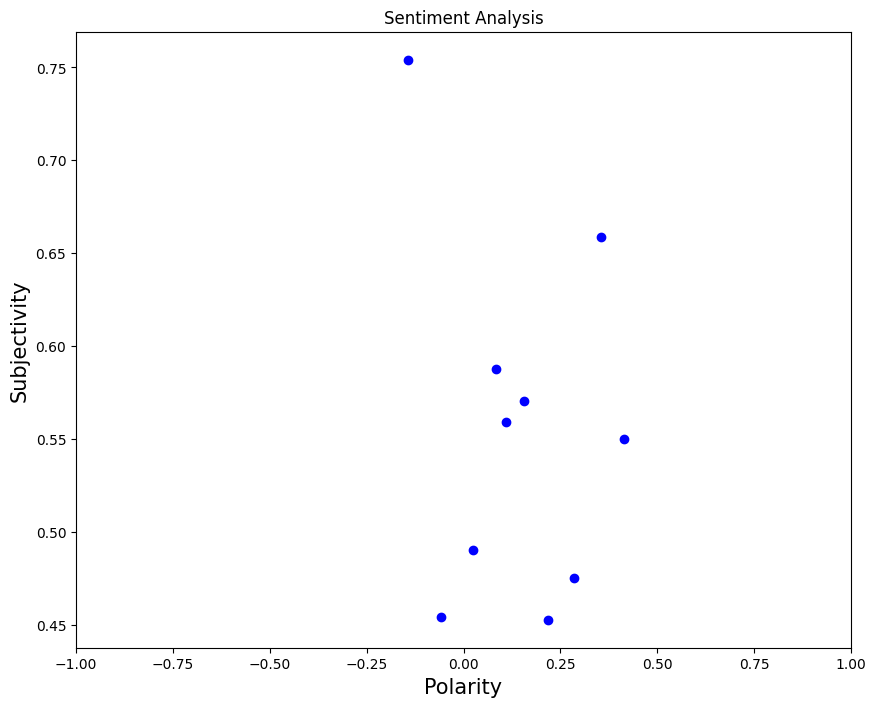

In [15]:
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [10, 8]

for index, review in enumerate(imdb.index):
  x = imdb.polarity.loc[review]
  y = imdb.subjectivity.loc[review]
  plt.scatter(x, y, color='blue')
  plt.xlim(-1,1)

plt.title('Sentiment Analysis')
plt.xlabel('Polarity', fontsize=15)
plt.ylabel('Subjectivity', fontsize=15)
plt.show()

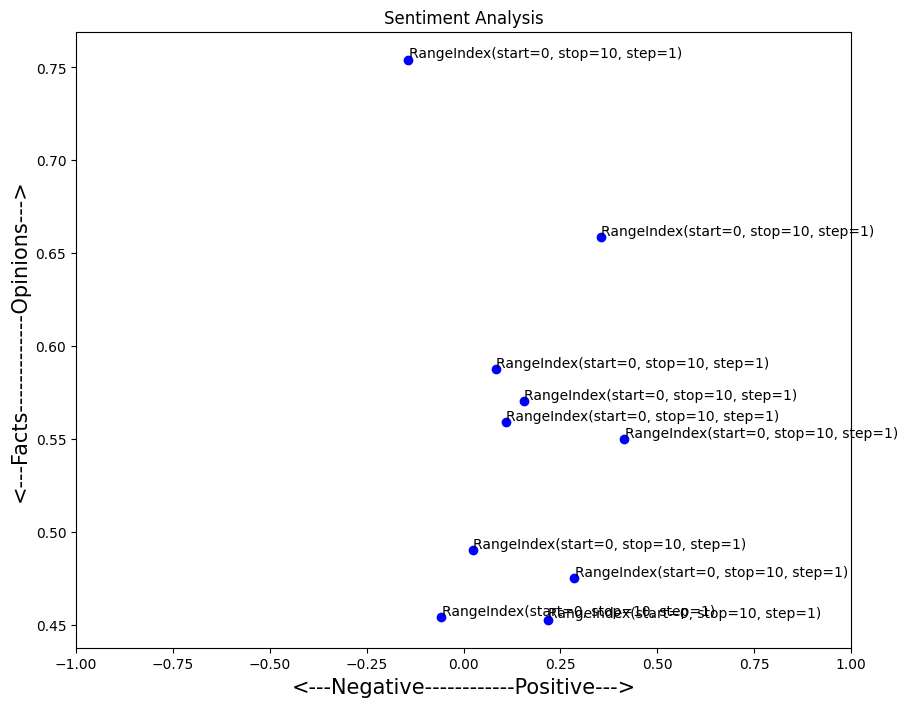

In [18]:
for index, review in enumerate(imdb.index):
  x = imdb.polarity.loc[review]
  y = imdb.subjectivity.loc[review]
  plt.scatter(x, y, color='blue')
  plt.text(x+.001, y+.001, imdb.index, fontsize=10)
  plt.xlim(-1,1)

plt.title('Sentiment Analysis')
plt.xlabel('<---Negative------------Positive--->', fontsize=15)
plt.ylabel('<---Facts-------------Opinions--->', fontsize=15)
plt.show()

## Perbandingan dengan Ground Truth

Kedua metode dibandingkan dengan ``label sentimen`` asli dari **IMDB**. Secara umum, Vader cenderung memberikan performa yang lebih baik untuk ulasan film karena:
* Pemahaman terhadap penguat: Vader lebih baik dalam memahami kata-kata penguat seperti **sangat** dan **terlalu**
Penanganan negasi yang lebih baik: Vader dapat menangani negasi dengan lebih baik, seperti dalam kalimat ``"Saya tidak suka film ini"``.

Analisis yang lebih kontekstual: Vader dapat mempertimbangkan konteks kalimat secara lebih baik, yang membantu dalam memahami sentimen yang lebih kompleks.

---

## 2. Topic Modelling
* Lakukanlah topic modelling terhadap dataset `topicmodelling.csv`
    * `Load dataset` menggunakan `read_csv`, kemudian bentuk menjadi dataframe.
    * Lakukan topic modelling berdasarkan kolom abstract.
    * Perhatikan notebook pada resources modul 5 untuk cara mengerjakan.
    * Cobalah beberapa **num_topics**, kemudian coba menggunakan 5 **num_topics**.
    * Bandingkan dengan table dataset awal apakah pengelompokan topik yang didapat sama dengan pada dataset (mis. Paper a,b, e masuk ke topik 1, dll). Topik pada table bisa dilihat pada kolom Computer Science, Physics, Mathematics, Statistics, Quantitative Biology, dimana angka 1 menandakan suatu paper masuk ke topik kolom tersebut.
    * Perhatikan juga apakah top words yang dihasilkan sesuai dengan topik-topik yang ada (Urutan topik bisa berbeda, Computer Science belum tentu menjadi topik pertama, dst.).

---

In [20]:
import scipy
from gensim import models
from gensim import matutils

In [23]:
papers = pd.read_csv('topicmodelling.csv')
papers

,ID,TITLE,ABSTRACT,Computer Science,Physics,Mathematics,Statistics,Quantitative Biology
0,1,Reconstructing Subject-Specific Effect Maps,Predictive models allow subject-specific inf...,1,0,0,0,0
1,2,Rotation Invariance Neural Network,Rotation invariance and translation invarian...,1,0,0,0,0
2,3,Spherical polyharmonics and Poisson kernels fo...,We introduce and develop the notion of spher...,0,0,1,0,0
3,4,A finite element approximation for the stochas...,The stochastic Landau--Lifshitz--Gilbert (LL...,0,0,1,0,0
4,5,Comparative study of Discrete Wavelet Transfor...,Fourier-transform infra-red (FTIR) spectra o...,1,0,0,1,0
5,6,On maximizing the fundamental frequency of the...,Let $\Omega \subset \mathbb{R}^n$ be a bound...,0,0,1,0,0
6,7,On the rotation period and shape of the hyperb...,We observed the newly discovered hyperbolic ...,0,1,0,0,0
7,8,Adverse effects of polymer coating on heat tra...,The ability of metallic nanoparticles to sup...,0,1,0,0,0
8,9,SPH calculations of Mars-scale collisions: the...,We model large-scale ($\approx$2000km) impac...,0,1,0,0,0
9,10,$\mathcal{R}_{0}$ fails to predict the outbrea...,Time varying susceptibility of host at indiv...,0,0,0,0,1


In [24]:
abstract = papers['ABSTRACT']
abstract

,ABSTRACT
0,Predictive models allow subject-specific inf...
1,Rotation invariance and translation invarian...
2,We introduce and develop the notion of spher...
3,The stochastic Landau--Lifshitz--Gilbert (LL...
4,Fourier-transform infra-red (FTIR) spectra o...
5,Let $\Omega \subset \mathbb{R}^n$ be a bound...
6,We observed the newly discovered hyperbolic ...
7,The ability of metallic nanoparticles to sup...
8,We model large-scale ($\approx$2000km) impac...
9,Time varying susceptibility of host at indiv...


In [25]:
import re
import string

In [31]:
def clean_text_round(text):
    '''Make text lowercase, remove text in square brackets, remove punctuation and remove words containing numbers.'''
    text = text.lower()
    text = re.sub('\[.*?\]', '', text)
    text = re.sub('[%s]' % re.escape(string.punctuation), '', text)
    text = re.sub('\w*\d\w*', '', text)
    text = re.sub(r'\b\w(1,2)\b', '', text)
    text = re.sub('\n', ' ', text)
    text = re.sub('\xa0', ' ', text)
    text = re.sub(' +', ' ', text)

    return text



In [32]:
abstract = abstract.apply(clean_text_round)
abstract

,ABSTRACT
0,predictive models allow subjectspecific infer...
1,rotation invariance and translation invarianc...
2,we introduce and develop the notion of spheri...
3,the stochastic landaulifshitzgilbert llg equa...
4,fouriertransform infrared ftir spectra of sam...
5,let omega subset mathbbrn be a bounded domain...
6,we observed the newly discovered hyperbolic m...
7,the ability of metallic nanoparticles to supp...
8,we model largescale impacts on a marslike pla...
9,time varying susceptibility of host at indivi...


In [33]:
from sklearn.feature_extraction.text import CountVectorizer

cvm = CountVectorizer(stop_words='english')
data_cvm = cvm.fit_transform(abstract)
data_dtmn = pd.DataFrame(data_cvm.toarray(), columns=cvm.get_feature_names_out())
# data_dtmn.index = abstract.index
data_dtmn

,ability,account,accuracy,achieve,ad,addition,address,adni,affect,aims,...,weak,wellstudied,widely,work,wrappertype,wtt,xd,yield,yields,zonal
0,0,0,1,0,1,0,0,3,0,1,...,0,0,1,0,1,0,0,1,1,0
1,0,0,0,3,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,3
3,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
4,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,3,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,6,0,0,0
6,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7,1,0,0,0,0,0,1,0,1,0,...,0,0,0,1,0,0,0,0,0,0
8,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9,0,1,0,0,0,1,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0


In [36]:
corpusn = matutils.Sparse2Corpus(scipy.sparse.csr_matrix(data_dtmn.transpose()))

id2wordn = dict((v, k) for k, v in cvm.vocabulary_.items())

In [37]:
id2wordn

{344: 'predictive',
 280: 'models',
 12: 'allow',
 430: 'subjectspecific',
 216: 'inference',
 21: 'analyzing',
 123: 'disease',
 370: 'related',
 14: 'alterations',
 292: 'neuroimaging',
 98: 'data',
 183: 'given',
 429: 'subjects',
 241: 'levels',
 184: 'global',
 203: 'identifiying',
 74: 'condition',
 346: 'presence',
 428: 'subject',
 246: 'local',
 108: 'detecting',
 134: 'effect',
 214: 'individual',
 269: 'measurement',
 165: 'extracted',
 491: 'widely',
 474: 'used',
 175: 'form',
 256: 'maps',
 359: 'rarely',
 159: 'existing',
 496: 'yield',
 296: 'noisy',
 110: 'detections',
 73: 'composed',
 124: 'dispersed',
 230: 'isolated',
 229: 'islands',
 30: 'article',
 353: 'propose',
 362: 'reconstruction',
 274: 'method',
 284: 'named',
 383: 'rsm',
 210: 'improve',
 279: 'modeling',
 26: 'approaches',
 322: 'particular',
 44: 'binary',
 60: 'classifiers',
 416: 'specifically',
 9: 'aims',
 363: 'reduce',
 295: 'noise',
 387: 'sampling',
 150: 'error',
 31: 'associated',
 475: 'us

In [47]:
ldan_models = models.LdaModel(corpus=corpusn, num_topics=3, id2word=id2wordn, passes=20, random_state=1 )
ldan_models.print_topics()

[(0,
  '0.010*"invariance" + 0.010*"functions" + 0.010*"poisson" + 0.008*"kernels" + 0.008*"polyharmonics" + 0.008*"zonal" + 0.008*"wtt" + 0.008*"liquid" + 0.008*"achieve" + 0.008*"polymer"'),
 (1,
  '0.015*"xd" + 0.013*"material" + 0.010*"muomega" + 0.010*"stochastic" + 0.010*"equation" + 0.010*"solutions" + 0.008*"terms" + 0.008*"domain" + 0.008*"state" + 0.008*"omega"'),
 (2,
  '0.023*"data" + 0.015*"epidemic" + 0.013*"used" + 0.013*"rsm" + 0.011*"model" + 0.011*"condition" + 0.011*"subjectspecific" + 0.011*"disease" + 0.011*"inference" + 0.008*"using"')]

In [44]:
ldan_models = models.LdaModel(corpus=corpusn, num_topics=2, id2word=id2wordn, passes=20, random_state=1 )
ldan_models.print_topics()

[(0,
  '0.016*"data" + 0.010*"used" + 0.008*"using" + 0.008*"rsm" + 0.007*"inference" + 0.007*"subjectspecific" + 0.007*"functions" + 0.007*"poisson" + 0.007*"invariance" + 0.005*"disease"'),
 (1,
  '0.011*"xd" + 0.011*"epidemic" + 0.010*"material" + 0.008*"model" + 0.008*"muomega" + 0.008*"equation" + 0.008*"stochastic" + 0.008*"solutions" + 0.008*"time" + 0.006*"terms"')]

In [46]:
corpus_transformed = ldan_models[corpusn]
list(zip([i[0][0] for i in corpus_transformed], data_dtmn.index))

[(0, 0),
 (0, 1),
 (0, 2),
 (1, 3),
 (0, 4),
 (1, 5),
 (0, 6),
 (0, 7),
 (1, 8),
 (1, 9)]

In [45]:
for i in corpus_transformed:
  print(i[0])

(0, 0.9969042)
(0, 0.9878011)
(1, 0.9906168)
(0, 0.9911361)
(1, 0.9928812)
(1, 0.9934021)
(0, 0.011632211)
(1, 0.9923187)
(1, 0.99090827)
(0, 0.9930464)


## 03 Text Generation
* Buatlah sebuah paragraph baru dengan mengenerate text berdasarkan dataset game_of_thrones.txt
* Load dataset dengan:
```python
    filename = '../input/game_of_thrones.txt'
    data = open(filename).read()
```
(Ingat: input text generation cukup dalam bentuk string).

* Perhatikan notebook pada resources modul 6 untuk cara mengerjakan.
* Buatlah sebuah paragraph baru dengan 10 kalimat (lakukan 10 kali looping saat
mengenerate sentence) dengan tiap kalimat terdiri dari 15 kata.
* Bacalah hasil text yang dihasilkan.

In [48]:
with open('game_of_thrones.txt', encoding='utf-8') as file:
    input_teks = file.read()
input_teks

"We should start back, Gared urged as the woods began to grow dark around them.  The wildlings are dead.\n\nDo the dead frighten you? Ser Waymar Royce asked with just the hint of a smile.\n\nGared did not rise to the bait. He was an old man, past fifty, and he had seen the lordlings come and go.  Dead is dead, he said.  We have no business with the dead.\n\nAre they dead? Royce asked softly.  What proof have we?\n\nWill saw them, Gared said.  If he says they are dead, that's proof enough for me.\n\nWill had known they would drag him into the quarrel sooner or later. He wished it had been later rather than sooner.  My mother told me that dead men sing no songs, he put in.\n\nMy wet nurse said the same thing, Will, Royce replied.  Never believe anything you hear at a woman's tit. There are things to be learned even from the dead. His voice echoed, too loud in the twilit forest.\n\nWe have a long ride before us, Gared pointed out.  Eight days, maybe nine. And night is falling.\n\nSer Waym

In [50]:
input_teks = re.sub('\n', '', input_teks)
input_teks

"We should start back, Gared urged as the woods began to grow dark around them.  The wildlings are dead.Do the dead frighten you? Ser Waymar Royce asked with just the hint of a smile.Gared did not rise to the bait. He was an old man, past fifty, and he had seen the lordlings come and go.  Dead is dead, he said.  We have no business with the dead.Are they dead? Royce asked softly.  What proof have we?Will saw them, Gared said.  If he says they are dead, that's proof enough for me.Will had known they would drag him into the quarrel sooner or later. He wished it had been later rather than sooner.  My mother told me that dead men sing no songs, he put in.My wet nurse said the same thing, Will, Royce replied.  Never believe anything you hear at a woman's tit. There are things to be learned even from the dead. His voice echoed, too loud in the twilit forest.We have a long ride before us, Gared pointed out.  Eight days, maybe nine. And night is falling.Ser Waymar Royce glanced at the sky with

In [52]:
from collections import defaultdict

def markov_chain(text):
    '''The input is a string of text and the output will be a dictionary with each word as
       a key and each value as the list of words that come after the key in the text.'''

    # Tokenize the text by word, though including punctuation
    words = text.split(' ')

    # Initialize a default dictionary to hold all of the words and next words
    m_dict = defaultdict(list)

    # Create a zipped list of all of the word pairs and put them in word: list of next words format
    for current_word, next_word in zip(words[0:-1], words[1:]):
        m_dict[current_word].append(next_word)

    # Convert the default dict back into a dictionary
    m_dict = dict(m_dict)
    return m_dict

In [53]:
# Create the dictionary for Ali's routine, take a look at it
spd_dict = markov_chain(input_teks)
spd_dict

{'We': ['should', 'have', 'found', 'can', 'need', 'will'],
 'should': ['start', 'track'],
 'start': ['back,'],
 'back,': ['Gared', 'and', 'and'],
 'Gared': ['urged',
  'said.',
  'pointed',
  'had',
  'had',
  'on',
  'told',
  'must',
  'said.',
  'said',
  'pulled',
  'said',
  'brought',
  'muttered.The',
  'asked.',
  'did',
  'said.',
  'pulled',
  'looked',
  'would',
  'still'],
 'urged': ['as'],
 'as': ['the',
  'though',
  'to',
  'a',
  'his',
  'sin.',
  'he',
  'we',
  'silent',
  'Will,',
  'I',
  'day.',
  'he',
  'he',
  'he',
  'reaching',
  'it',
  'Ser',
  'the',
  'Will',
  'old',
  'milk.',
  'it',
  'new-fallen',
  'shadow,',
  'fire',
  'if',
  'if',
  'icicles.When'],
 'the': ['woods',
  'dead',
  'hint',
  'bait.',
  'lordlings',
  'dead.Are',
  'quarrel',
  'same',
  'dead.',
  'twilit',
  'sky',
  'dark,',
  'tightness',
  'barely',
  'thick',
  "Night's",
  'wounded',
  'older',
  'Wall.',
  'old',
  'endless',
  'southron',
  'haunted',
  'Wall,',
  'track',

In [54]:
import random

def generate_sentence(chain, count=15):
    '''Input a dictionary in the format of key = current word, value = list of next words
       along with the number of words you would like to see in your generated sentence.'''

    # Capitalize the first word
    word1 = random.choice(list(chain.keys()))
    sentence = word1.capitalize()

    # Generate the second word from the value list. Set the new word as the first word. Repeat.
    for i in range(count-1):
        word2 = random.choice(chain[word1])
        word1 = word2
        sentence += ' ' + word2

    # End it with a period
    sentence += '.'
    return(sentence)

In [55]:
generate_sentence(spd_dict)

'Burning, but a meal he had felt it that it now, his saddle. He had.'